In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
print("Python executable:")
print(sys.executable)

print("\nTensorFlow version:")
print(tf.__version__)

print("\nGPU Available:")
print(tf.config.list_physical_devices('GPU'))

Python executable:
C:\Users\User\anaconda3\envs\pneumonia_ai\python.exe

TensorFlow version:
2.21.0

GPU Available:
[]


In [3]:
TRAIN_PATH = "combined_dataset/train"
VALID_PATH = "combined_dataset/valid"
TEST_PATH = "combined_dataset/test"

print("Train Path:", TRAIN_PATH)
print("Validation Path:", VALID_PATH)
print("Test Path:", TEST_PATH)

Train Path: combined_dataset/train
Validation Path: combined_dataset/valid
Test Path: combined_dataset/test


In [4]:
print("Training folders:")
print(os.listdir(TRAIN_PATH))

print("\nValidation folders:")
print(os.listdir(VALID_PATH))

print("\nTesting folders:")
print(os.listdir(TEST_PATH))

Training folders:
['Normal', 'Pneumonia', 'Tuberculosis']

Validation folders:
['Normal', 'Pneumonia', 'Tuberculosis']

Testing folders:
['Normal', 'Pneumonia', 'Tuberculosis']


In [5]:
classes = ["Normal", "Pneumonia", "Tuberculosis"]

for split_name, split_path in [
    ("Train", TRAIN_PATH),
    ("Validation", VALID_PATH),
    ("Test", TEST_PATH)
]:
    
    print("\n" + "=" * 50)
    print(split_name)
    print("=" * 50)
    
    total = 0
    
    for class_name in classes:
        class_path = os.path.join(split_path, class_name)
        
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        
        print(class_name, ":", count)
        total += count
    
    print("Total:", total)


Train
Normal : 1491
Pneumonia : 2973
Tuberculosis : 1166
Total: 5630

Validation
Normal : 805
Pneumonia : 861
Tuberculosis : 250
Total: 1916

Test
Normal : 241
Pneumonia : 411
Tuberculosis : 250
Total: 902


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3

print("Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)
print("Number of Classes:", NUM_CLASSES)

Image Size: (224, 224)
Batch Size: 32
Number of Classes: 3


In [9]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    shear_range=0.10,
    brightness_range=[0.9, 1.1],
    
    horizontal_flip=False,
    
    fill_mode="nearest"
)

print("Training data generator created.")

Training data generator created.


In [10]:
valid_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

print("Validation and test data generator created.")

Validation and test data generator created.


In [11]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

validation_generator = valid_test_datagen.flow_from_directory(
    VALID_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nTrain Images:", train_generator.samples)
print("Validation Images:", validation_generator.samples)
print("Test Images:", test_generator.samples)

print("\nClass Mapping:")
print(train_generator.class_indices)

Found 5630 images belonging to 3 classes.
Found 1916 images belonging to 3 classes.
Found 902 images belonging to 3 classes.

Train Images: 5630
Validation Images: 1916
Test Images: 902

Class Mapping:
{'Normal': 0, 'Pneumonia': 1, 'Tuberculosis': 2}


In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = train_generator.classes

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(
    enumerate(class_weights_array)
)

print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(1.2586630896490052), 1: np.float64(0.6312366857270995), 2: np.float64(1.6094911377930246)}


In [14]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("DenseNet121 loaded successfully.")

DenseNet121 loaded successfully.


In [15]:
base_model.trainable = False

print("DenseNet121 backbone frozen.")

DenseNet121 backbone frozen.


In [16]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dropout(0.4)(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = Dropout(0.3)(x)

output = Dense(
    3,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

print("DenseNet121 classification model created.")

DenseNet121 classification model created.


In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d                │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,408 │ zero_padding2d[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_1              │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 56, 56, 64)        │               0 │ zero_padding2d_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 56, 56, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 56, 56, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 7,305,795 (27.87 MB)

 Trainable params: 265,731 (1.01 MB)

 Non-trainable params: 7,040,064 (26.86 MB)

In [18]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [19]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "DenseNet121_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks = [
    early_stopping,
    reduce_lr,
    checkpoint
]

print("Callbacks created.")

Callbacks created.


In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7187 - loss: 0.6474
Epoch 1: val_loss improved from None to 0.30134, saving model to DenseNet121_best.keras

Epoch 1: finished saving model to DenseNet121_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.7187 - loss: 0.6474 - val_accuracy: 0.9087 - val_loss: 0.3013 - learning_rate: 1.0000e-04
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8547 - loss: 0.3667
Epoch 2: val_loss improved from 0.30134 to 0.18681, saving model to DenseNet121_best.keras

Epoch 2: finished saving model to DenseNet121_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.8547 - loss: 0.3667 - val_accuracy: 0.9379 - val_loss: 0.1868 - learning_rate: 1.0000e-04
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8773 - loss: 0.3005
Epoch 3: val_loss improved from 0.18681 to 0.15771, saving model to DenseNet121_best.keras

Epoch 3: finished saving model to DenseNet121_best.keras
176/176 ━

In [20]:
from tensorflow.keras.models import load_model

# Load the best saved DenseNet121 model
model = load_model("DenseNet121_best.keras")

print("Best DenseNet121 model loaded successfully.")

Best DenseNet121 model loaded successfully.


In [21]:
history_resume = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    initial_epoch=10,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 11/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9234 - loss: 0.2023
Epoch 11: val_loss improved from None to 0.10320, saving model to DenseNet121_best.keras

Epoch 11: finished saving model to DenseNet121_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 413s 2s/step - accuracy: 0.9234 - loss: 0.2023 - val_accuracy: 0.9635 - val_loss: 0.1032 - learning_rate: 1.0000e-04
Epoch 12/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9266 - loss: 0.1881
Epoch 12: val_loss improved from 0.10320 to 0.10113, saving model to DenseNet121_best.keras

Epoch 12: finished saving model to DenseNet121_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - accuracy: 0.9266 - loss: 0.1881 - val_accuracy: 0.9645 - val_loss: 0.1011 - learning_rate: 1.0000e-04
Epoch 13/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9242 - loss: 0.1875
Epoch 13: val_loss did not improve from 0.10113
176/176 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.9242 - loss: 0.1875 - val_accuracy: 0.9603 - va

In [22]:
# Evaluate the best DenseNet121 model on the test set

test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("\n" + "=" * 60)
print("DENSENET121 TEST RESULTS")
print("=" * 60)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print("=" * 60)

29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9523 - loss: 0.1293

DENSENET121 TEST RESULTS
Test Loss     : 0.1293
Test Accuracy : 0.9523
Test Accuracy : 95.23%


In [23]:
import numpy as np

# Reset test generator before prediction
test_generator.reset()

y_prob = model.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

print("Predictions generated successfully.")
print("Number of test samples :", len(y_true))
print("Number of predictions  :", len(y_pred))

29/29 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step
Predictions generated successfully.
Number of test samples : 902
Number of predictions  : 902


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print("\n" + "=" * 70)
print("DENSENET121 CLASSIFICATION RESULTS")
print("=" * 70)

print(f"Accuracy  : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Pneumonia", "Tuberculosis"],
        digits=4,
        zero_division=0
    )
)


DENSENET121 CLASSIFICATION RESULTS
Accuracy  : 0.9523 (95.23%)
Precision : 0.9490
Recall    : 0.9591
F1-Score  : 0.9525

Classification Report:
              precision    recall  f1-score   support

      Normal     0.8640    0.9751    0.9162       241
   Pneumonia     0.9870    0.9221    0.9535       411
Tuberculosis     0.9959    0.9800    0.9879       250

    accuracy                         0.9523       902
   macro avg     0.9490    0.9591    0.9525       902
weighted avg     0.9566    0.9523    0.9530       902



<Figure size 700x600 with 0 Axes>

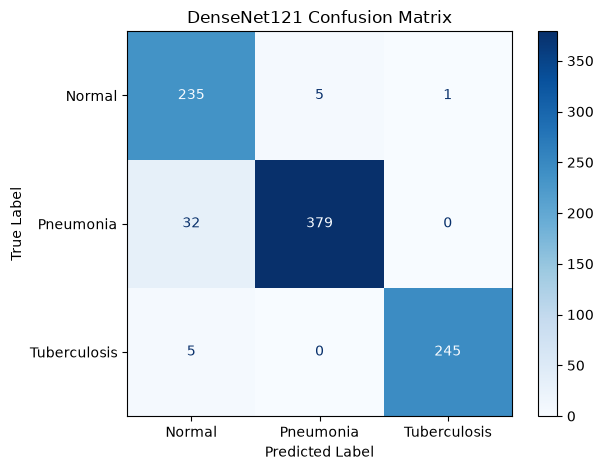

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = [
    "Normal",
    "Pneumonia",
    "Tuberculosis"
]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("DenseNet121 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

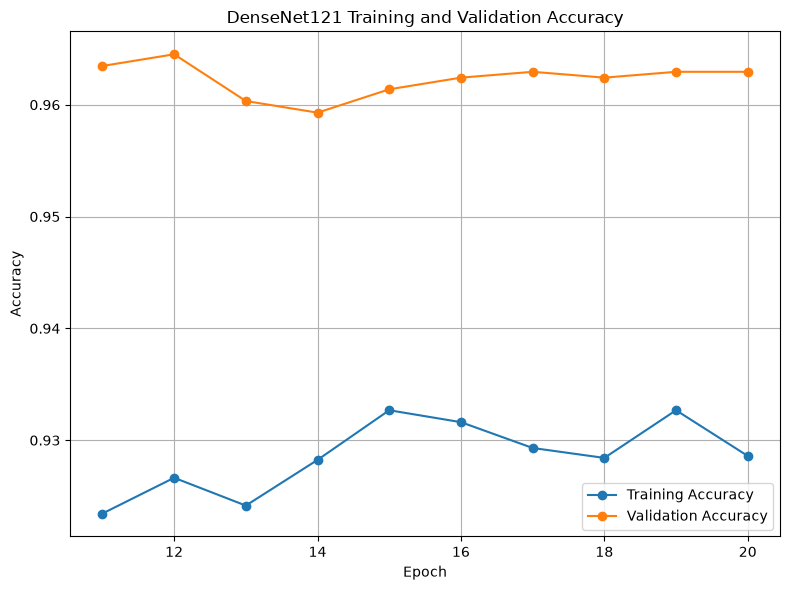

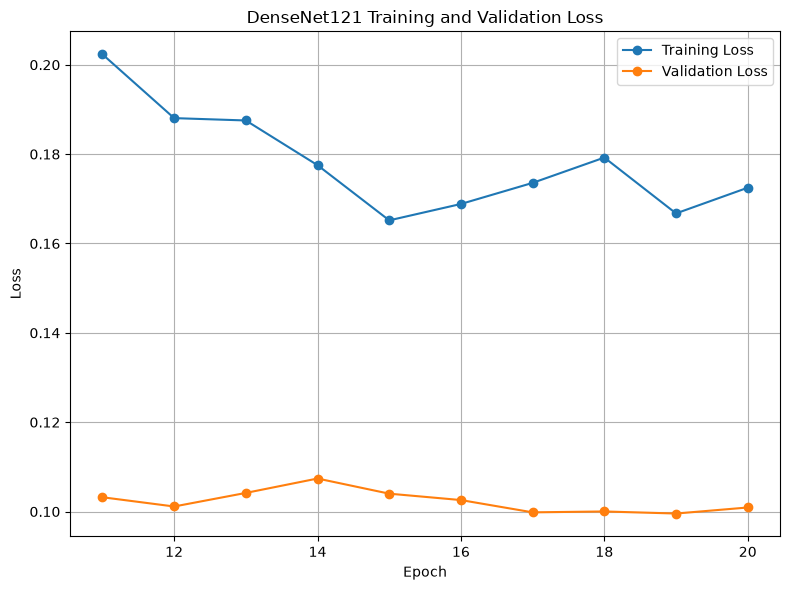

Graphs saved successfully:
DenseNet121_accuracy.svg
DenseNet121_loss.svg


In [27]:
import matplotlib.pyplot as plt

# Use the history from resumed training
acc = history_resume.history["accuracy"]
val_acc = history_resume.history["val_accuracy"]
loss = history_resume.history["loss"]
val_loss = history_resume.history["val_loss"]

# Resumed training started from epoch 11
start_epoch = 11
epochs = range(start_epoch, start_epoch + len(acc))


# ============================================================
# 1. ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    acc,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_acc,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet121 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "DenseNet121_accuracy.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 2. LOSS GRAPH
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "DenseNet121_loss.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("Graphs saved successfully:")
print("DenseNet121_accuracy.svg")
print("DenseNet121_loss.svg")

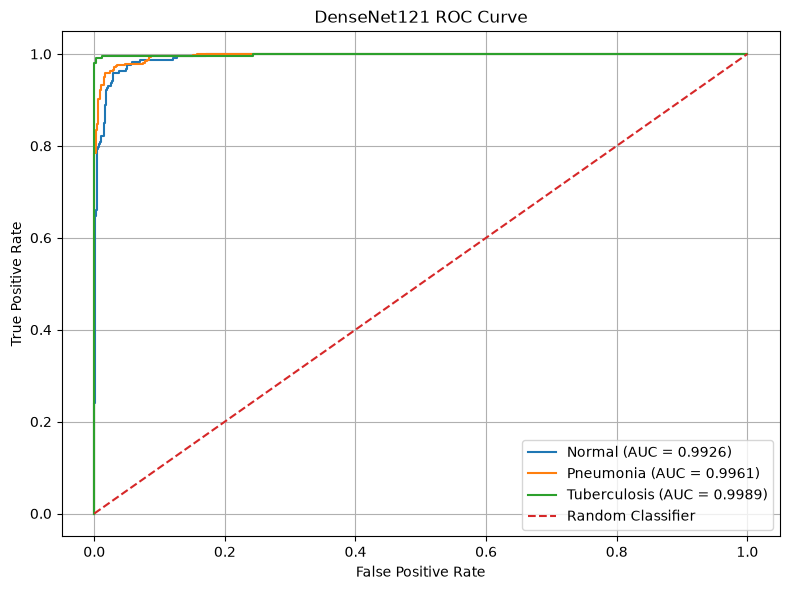


DenseNet121 AUC Results:
Normal: 0.9926
Pneumonia: 0.9961
Tuberculosis: 0.9989

Saved: DenseNet121_ROC.svg


In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

class_names = ["Normal", "Pneumonia", "Tuberculosis"]

# Convert true labels to one-hot format
y_true_bin = label_binarize(
    y_true,
    classes=[0, 1, 2]
)

plt.figure(figsize=(8, 6))

auc_values = {}

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)
    auc_values[class_name] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.4f})"
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DenseNet121 ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save as SVG for your paper
plt.savefig(
    "DenseNet121_ROC.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("\nDenseNet121 AUC Results:")
for class_name, value in auc_values.items():
    print(f"{class_name}: {value:.4f}")

print("\nSaved: DenseNet121_ROC.svg")